# 01 — Norms, Descriptives & Inter-Individual Differences
Covers RQ2: OCEAN score distributions, normality tests, human BFI benchmarking,
social desirability correlations, and refusal/completion rates.

In [1]:
### 0) IMPORTS
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, kstest

from src.reading_data import create_final_dfs
from src.visualizations import (
    apply_paper_style,
    OCEAN_COLS,
    IMPACT_SIX,
    HUMAN_BFI_NORMS,
    descriptive_stats,
    ks_normality_tests,
    plot_ocean_distributions,
    plot_trait_correlation_heatmap,
    plot_trait_covariances
)

os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_soc_des, df_metadata, df_lmm = create_final_dfs()


Created dataframes:
df_all:      (130970, 16)
df_A:        (13098, 18)
df_B:        (222, 7)
df_cfa:      (222, 44)
df_cfa_soc_des: (222, 59)
df_metadata: (222, 22)
df_lmm:      (96933, 11)


## 1.1 Descriptive Statistics

In [3]:
### 2) DESCRIPTIVE STATISTICS
# Mean, SD, min, max across all models for each OCEAN trait + social desirability
desc_cols = OCEAN_COLS + ["social-desirability"]
desc_stats = descriptive_stats(df_B, cols=desc_cols)

n_models = df_metadata["model"].nunique()

families = (
    df_metadata["Family"]
    .dropna()
    .astype(str)
    .str.lower()
    .nunique()
)

families_vals = (
    df_metadata["Family"]
    .dropna()
    .astype(str)
    .str.lower()
    .unique()
)

regions = (
    df_metadata["Region"]
    .dropna()
    .value_counts()
)

licenses = (
    df_metadata["license_group"]
    .value_counts(dropna=False)
)

reasoning_counts = (
    df_metadata["Reasoning"]
    .astype(str)
    .str.lower()
    .value_counts()
)

release_dates = pd.to_datetime(
    df_metadata["Release_date"],
    errors="coerce"
)

min_release = release_dates.min()
max_release = release_dates.max()

params = pd.to_numeric(
    df_metadata["params_numeric"],
    errors="coerce"
)

min_params = params.min()
max_params = params.max()

total_rows = len(df_all)

valid_mask = pd.to_numeric(
    df_all["response"],
    errors="coerce"
).isin([1, 2, 3, 4, 5])

n_valid = valid_mask.sum()
n_invalid = (~valid_mask).sum()

completion_rate = n_valid / total_rows * 100
refusal_rate = n_invalid / total_rows * 100

model_refusal = (
    df_all.assign(
        valid=pd.to_numeric(
            df_all["response"],
            errors="coerce"
        ).isin([1, 2, 3, 4, 5])
    )
    .groupby("model")
    .agg(
        total=("valid", "size"),
        valid=("valid", "sum")
    )
)

model_refusal["refusal_rate"] = (
    1 - (model_refusal["valid"] / model_refusal["total"])
) * 100

dispersion = (
    df_B[OCEAN_COLS]
    .agg(["mean", "std", "min", "max"])
    .T
    .round(3)
)

country_family = (
    df_metadata[["Region", "Family"]]
    .dropna()
    .drop_duplicates()
    .groupby("Region")["Family"]
    .apply(lambda x: sorted(x.astype(str).unique()))
)

In [4]:
print("=== Descriptive Statistics ===")

print(f"N models: {n_models}")
print(f"N model families: {families}")
print(f"Families: {families_vals}")

print("\nRegions:")
print(regions.to_string())

for country, fams in country_family.items():
    print(f"\n{country}:")
    for f in fams:
        print(f"  - {f}")

print("\nLicense groups:")
print(licenses.to_string())

print("\nReasoning models:")
print(reasoning_counts.to_string())

print("\nRelease date range:")
print(f"{min_release.date()} to {max_release.date()}")

print("\nParameter scale:")
print(f"{min_params:.2f}B to {max_params:.2f}B")

print("\n\n=====\n\n")

print(f"Total responses: {total_rows:,}")
print(f"Valid responses: {n_valid:,}")
print(f"Invalid / refusal responses: {n_invalid:,}")

print(f"\nCompletion rate: {completion_rate:.2f}%")
print(f"Refusal rate: {refusal_rate:.2f}%")

print("\n\n=====\n\n")

print(
    model_refusal["refusal_rate"]
    .describe()
    .round(2)
    .to_string()
)

print("\nTop 20 highest refusal rates:")
print(
    model_refusal["refusal_rate"]
    .sort_values(ascending=False)
    .head(20)
    .round(2)
    .to_string()
)

=== Descriptive Statistics ===
N models: 222
N model families: 22
Families: <StringArray>
[    'qwen',   'claude',     'seed',    'other',  'minimax',     'mimo',
 'deepseek',   'gemini',    'gemma',    'llama',  'mistral',     'kimi',
 'nemotron',  'gpt-oss',      'glm',      'gpt', 'o-series',     'aion',
  'trinity',    'ernie',    'sonar',     'grok']
Length: 22, dtype: str

Regions:
Region
china    97
US       96
EU       20
other     9

EU:
  - mistral

US:
  - claude
  - gemini
  - gemma
  - gpt
  - gpt-oss
  - grok
  - llama
  - nemotron
  - o-series
  - other
  - sonar
  - trinity

china:
  - deepseek
  - ernie
  - glm
  - kimi
  - mimo
  - minimax
  - other
  - qwen
  - seed

other:
  - aion
  - other

License groups:
license_group
open-weight    113
proprietary    109

Reasoning models:
Reasoning
false    130
true      92

Release date range:
2023-07-02 to 2026-04-30

Parameter scale:
0.27B to 1020.00B


=====


Total responses: 130,970
Valid responses: 130,005
Invalid / ref

In [5]:
print(desc_stats.round(2).to_string())

                     Mean    SD   Min    Q1  Median    Q3   Max
dimension                                                      
Agreeableness        4.09  0.49  2.69  3.89    4.30  4.44  4.74
Conscientiousness    4.13  0.56  2.56  3.77    4.31  4.56  4.99
Extraversion         3.69  0.46  2.45  3.44    3.72  4.01  4.95
Neuroticism          1.98  0.52  1.09  1.58    1.85  2.41  3.51
Openness             3.77  0.60  1.80  3.55    3.87  4.14  4.76
social-desirability  3.79  0.54  1.80  3.61    3.90  4.12  4.65


## 1.2 Normality Tests (Kolmogorov–Smirnov)

In [6]:
### 3) KS NORMALITY TESTS
ks_results = ks_normality_tests(df_metadata, cols=OCEAN_COLS)

print("=== Kolmogorov–Smirnov Normality Tests ===")
print(ks_results.to_string(index=False))

=== Kolmogorov–Smirnov Normality Tests ===
            trait     D     p interpretation
    Agreeableness 0.191 0.000     non-normal
Conscientiousness 0.147 0.000     non-normal
     Extraversion 0.053 0.547 approx. normal
      Neuroticism 0.109 0.009     non-normal
         Openness 0.124 0.002     non-normal


## 1.3 OCEAN Score Distributions — All Models
Boxplot (with human BFI baseline), histogram + KDE, and QQ-plot per trait.

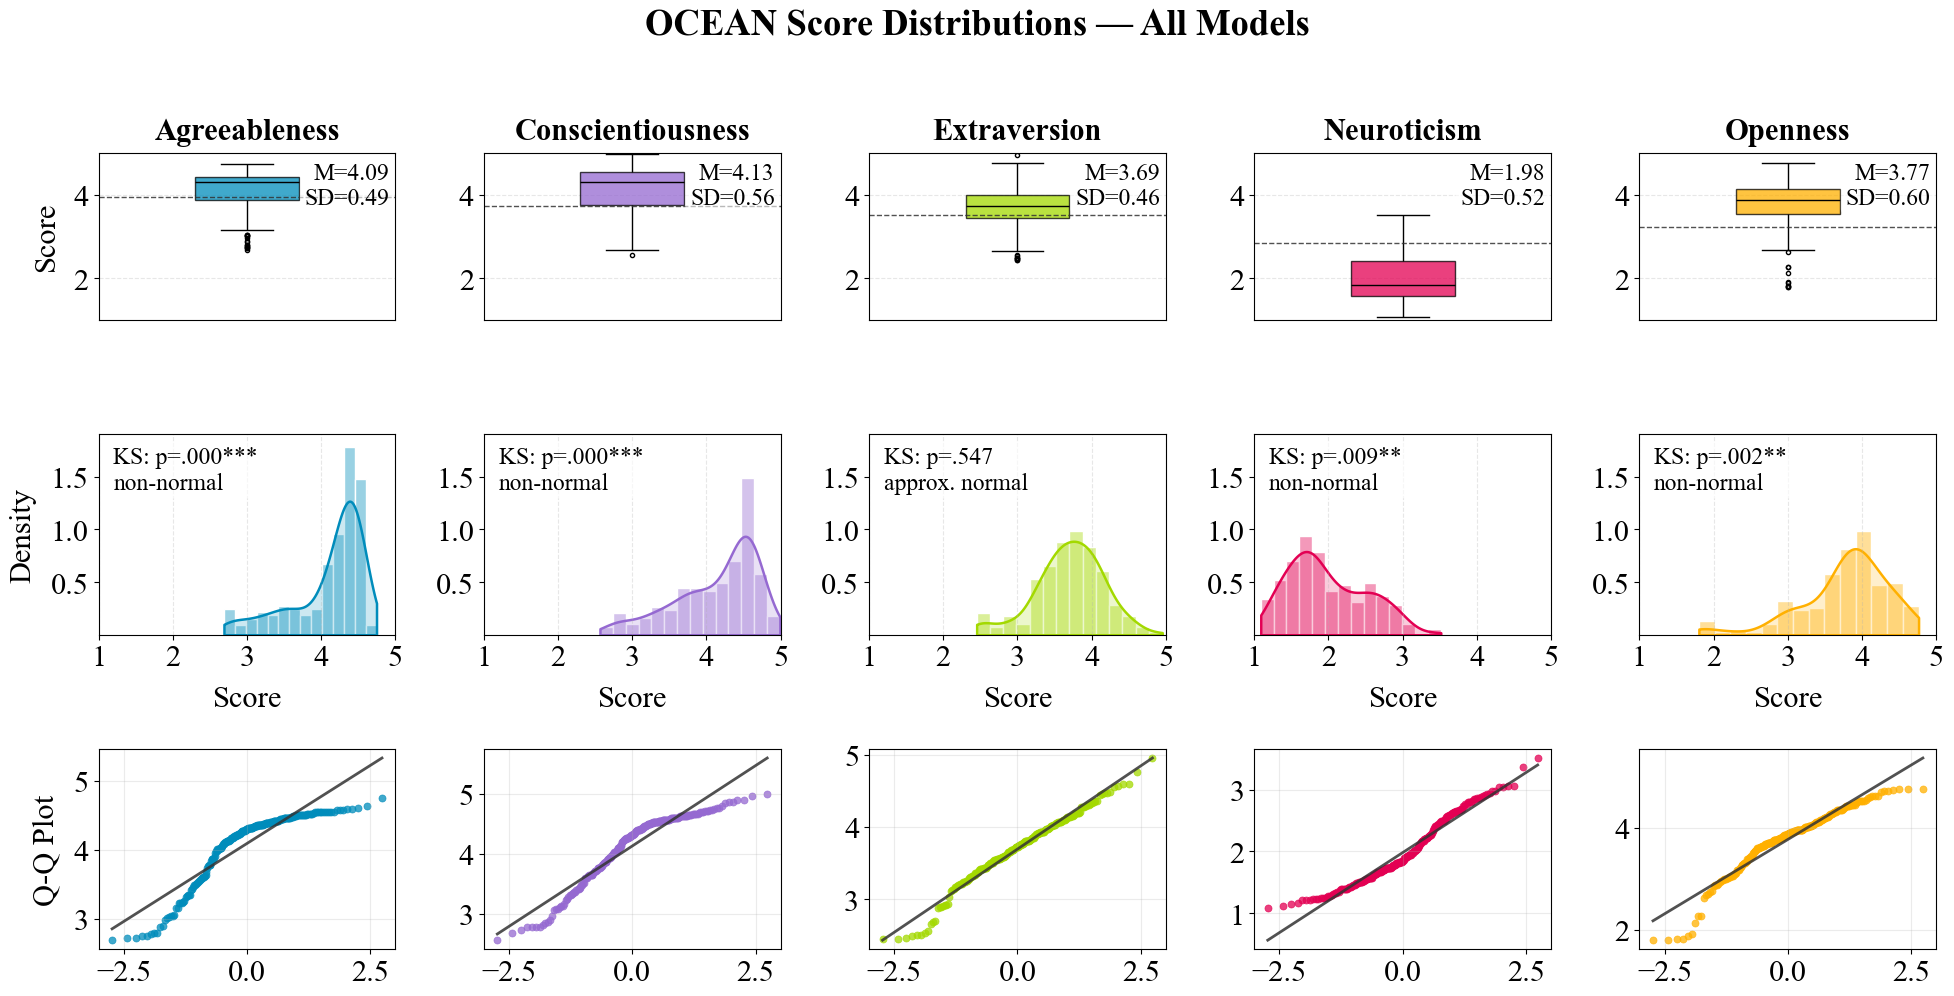

In [7]:
### 4) DISTRIBUTION FIGURE (RQ2)
fig = plot_ocean_distributions(
    df_metadata,
    cols=OCEAN_COLS,
    title="OCEAN Score Distributions — All Models",
    save_path="../../doc/figs/fig_ocean_all_models.pdf",
)
plt.show()

## 1.4 Social Desirability Correlations

In [8]:
### 5) PEARSON CORRELATIONS WITH SOCIAL DESIRABILITY
sd_col = "social-desirability"

sd_corrs = []
for trait in OCEAN_COLS:
    tmp = df_B[[trait, sd_col]].dropna()
    r   = tmp[trait].corr(tmp[sd_col], method="pearson")
    sd_corrs.append({"Trait": trait, "r_with_SD": r})

df_sd_corr = pd.DataFrame(sd_corrs)
print("=== Pearson Correlations with Social Desirability ===")
print(df_sd_corr.round(3).to_string(index=False))

=== Pearson Correlations with Social Desirability ===
            Trait  r_with_SD
    Agreeableness      0.771
Conscientiousness      0.729
     Extraversion      0.702
      Neuroticism     -0.515
         Openness      0.687


## 1.5 Trait Correlations (from 5-factor solution CFA)

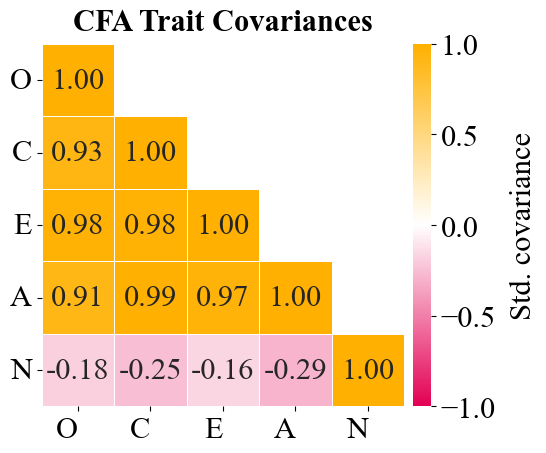

In [9]:
### 6) COVARIANCES HEATMAP FROM CFA
cov_vals = {
    ("Extraversion", "Agreeableness"): 0.966,
    ("Extraversion", "Conscientiousness"): 0.978,
    ("Extraversion", "Neuroticism"): -0.160,
    ("Extraversion", "Openness"): 0.981,

    ("Agreeableness", "Conscientiousness"): 0.993,
    ("Agreeableness", "Neuroticism"): -0.293,
    ("Agreeableness", "Openness"): 0.913,

    ("Conscientiousness", "Neuroticism"): -0.251,
    ("Conscientiousness", "Openness"): 0.927,

    ("Neuroticism", "Openness"): -0.185,
}

fig = plot_trait_covariances(
    cov_vals,
    title="CFA Trait Covariances",
    save_path="../../doc/figs/fig_covariance_heatmap.pdf"
)